In [ ]:
# Cargamos la librerías que vamos a necesitar para poder abordar el problema
import numpy as np
import pandas as pd
import torch
from torch import nn
import time
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/alumnos/davidase/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/alumnos/davidase/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
def modelo3D(t, z, λ, K, β, γ, b, δ):
  x, y, v = z

  # Sistema dinámico simplificado (Tian 2011: βv = βy = 0)
  dx = λ * x * (1 - (x + y) / K) - β * x * v
  dy = β * x * v - γ * y
  dv = -β * x * v + b * γ * y - δ * v

  return [dx, dy, dv]

In [ ]:
def model_adim(t, z, r, a, b, c):
    x, y, v = z
    dx = r * x * (1 - x - y) - a * x * v
    dy = a * x * v - y
    dv = b * y - a * x * v - c * v
    return [dx, dy, dv]

## Parámetros del modelo y condiciones iniciales

In [ ]:
# Parámetros adimensionales del modelo de Tian (adimensionalización con γ=1, K=1)
c = 0.2     # Tasa de eliminación del virus

b_true = 9.0
a_true = 0.11
r_true = 0.36

# Condiciones iniciales
x0 = 0.5    # Células sanas iniciales
y0 = 0.5    # Células infectadas iniciales
v0 = 1.5    # Carga viral inicial

# Tiempo máximo de simulación
TAU_MAX = 200.0

## Generación de datos sintéticos de entrenamiento

Simulamos el sistema con el valor verdadero `b_true` para obtener observaciones
a las que añadimos ruido gaussiano. Estas observaciones son los "datos clínicos"
que la PINN usará para estimar `b`.

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# Número de puntos de observación
N_OBS = 50

# Tiempos de observación distribuidos uniformemente en [0, TAU_MAX]
t_obs_np = np.linspace(0, TAU_MAX, N_OBS)

# Solución de referencia con b_true
sol_data = solve_ivp(
    model_adim,
    [0, TAU_MAX],
    [x0, y0, v0],
    args=(r_true, a_true, b_true, c),
    t_eval=t_obs_np,
    method='LSODA',
    rtol=1e-8, atol=1e-10
)

# Nivel de ruido relativo
noise_level = 0.0

x_clean = sol_data.y[0]
y_clean = sol_data.y[1]
v_clean = sol_data.y[2]

x_noisy = x_clean + noise_level * np.std(x_clean) * np.random.randn(N_OBS)
y_noisy = y_clean + noise_level * np.std(y_clean) * np.random.randn(N_OBS)
v_noisy = v_clean + noise_level * np.std(v_clean) * np.random.randn(N_OBS)

# Convertimos a tensores de PyTorch
t_data   = torch.tensor(t_obs_np,  dtype=torch.float32).view(-1, 1)
x_data   = torch.tensor(x_noisy,   dtype=torch.float32).view(-1, 1)
y_data   = torch.tensor(y_noisy,   dtype=torch.float32).view(-1, 1)
v_data   = torch.tensor(v_noisy,   dtype=torch.float32).view(-1, 1)

print(f"Datos generados: {N_OBS} observaciones en t ∈ [0, {TAU_MAX}]")
print(f"Valor verdadero de b: {b_true}")
print(f"Valor verdadero de a: {a_true}")
print(f"Valor verdadero de r: {r_true}")

Datos generados: 50 observaciones en t ∈ [0, 200.0]
Valor verdadero de b: 9.0
Valor verdadero de a: 0.11
Valor verdadero de r: 0.36


## Visualización de los datos de entrenamiento

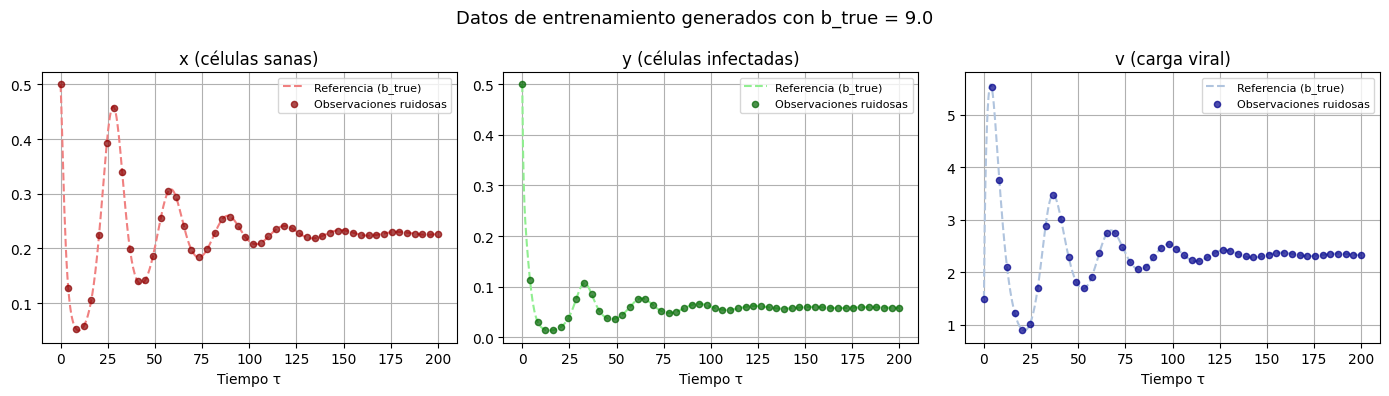

In [ ]:
t_ref_np = np.linspace(0, TAU_MAX, 500)
sol_ref = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r_true, a_true, b_true, c), t_eval=t_ref_np, method='LSODA'
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_var = ['x (células sanas)', 'y (células infectadas)', 'v (carga viral)']
colors_ref = ['lightcoral', 'lightgreen', 'lightsteelblue']
colors_data = ['darkred', 'darkgreen', 'darkblue']

for i, ax in enumerate(axes):
    ax.plot(t_ref_np, sol_ref.y[i], '--', color=colors_ref[i], label='Referencia (b_true)')
    noisy = [x_noisy, y_noisy, v_noisy][i]
    ax.scatter(t_obs_np, noisy, s=20, color=colors_data[i], alpha=0.7, zorder=5, label='Observaciones ruidosas')
    ax.set_xlabel('Tiempo τ')
    ax.set_title(labels_var[i])
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(f'Datos de entrenamiento generados con b_true = {b_true}', fontsize=13)
plt.tight_layout()
plt.show()

## Arquitectura de la PINN

In [ ]:
class VIRO_NN(nn.Module):
    """Red neuronal para el problema inverso de viroterapia.

    Aproxima la solución (x(t), y(t), v(t)) del sistema adimensionalizado
    de Tian mientras co-estima el parámetro b (tamaño de explosión viral).
    """

    def __init__(self, N_HIDDEN, N_LAYERS, x0=0.5, y0=0.5, v0=1.5):
        super().__init__()
        activation = nn.SiLU  # Tanh: gradientes suaves, adecuada para PINNs

        self.x0 = x0
        self.y0 = y0
        self.v0 = v0

        N_INPUT  = 1
        N_OUTPUT = 3

        # Capa de entrada
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        # Capas ocultas
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)
        ])
        # Capa de salida
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, t):
        # Normalización al intervalo [0, 1]
        tau = t / TAU_MAX

        out = self.fcs(tau)
        out = self.fch(out)
        out = self.fce(out)

        # Ansatz: garantiza condiciones iniciales exactas
        x = self.x0 + tau * out[:, 0:1]
        y = self.y0 + tau * out[:, 1:2]
        v = self.v0 + tau * out[:, 2:3]

        return torch.cat([x, y, v], dim=1)

INICIANDO SIMULACIÓN PARA 50 PACIENTES 


ENTRENANDO PACIENTE 1/50


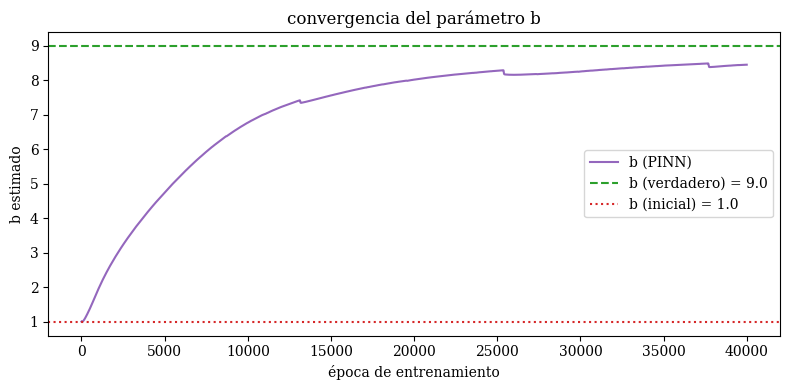


ENTRENANDO PACIENTE 2/50


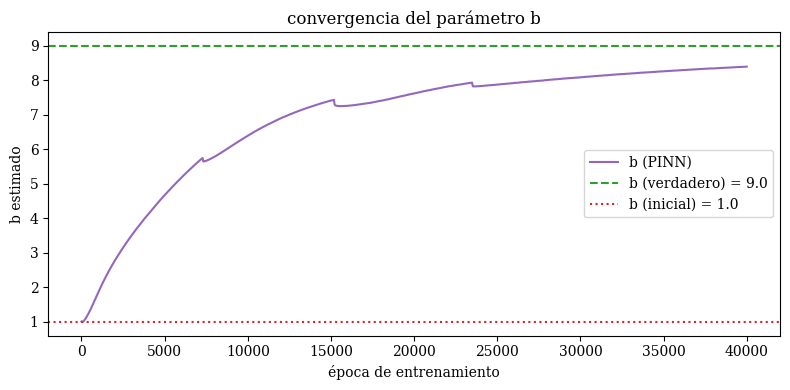


ENTRENANDO PACIENTE 3/50


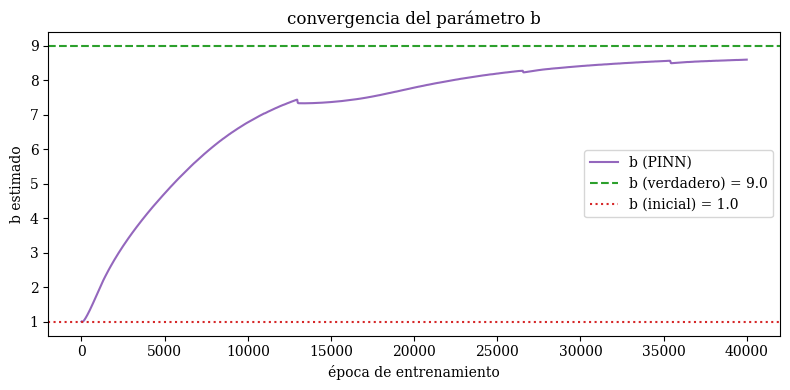


ENTRENANDO PACIENTE 4/50


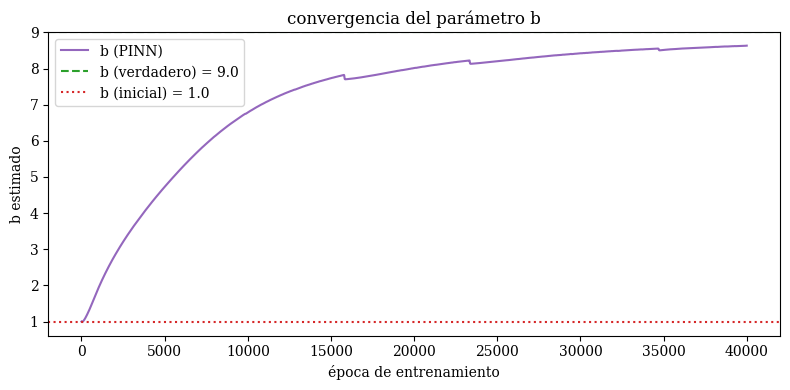


ENTRENANDO PACIENTE 5/50


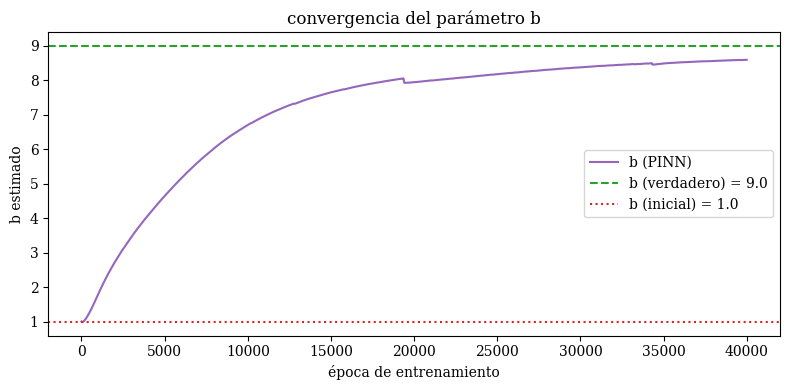


ENTRENANDO PACIENTE 6/50


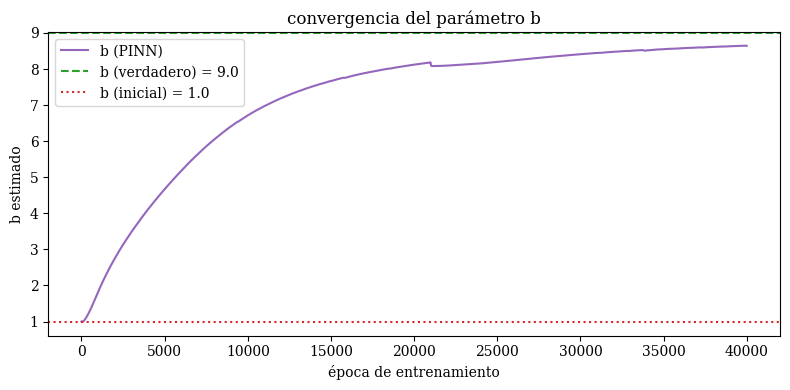


ENTRENANDO PACIENTE 7/50


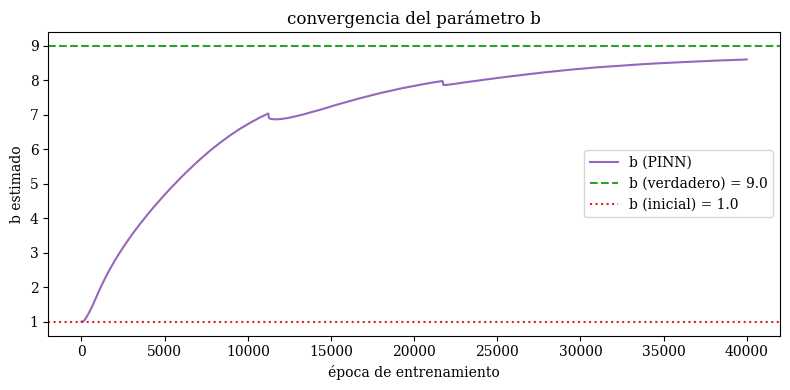


ENTRENANDO PACIENTE 8/50


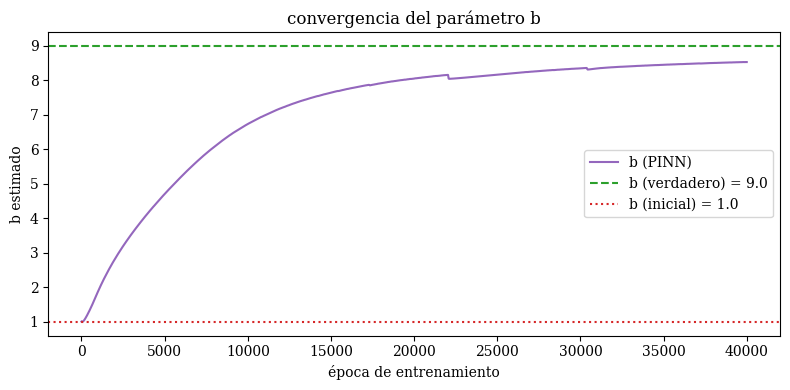


ENTRENANDO PACIENTE 9/50


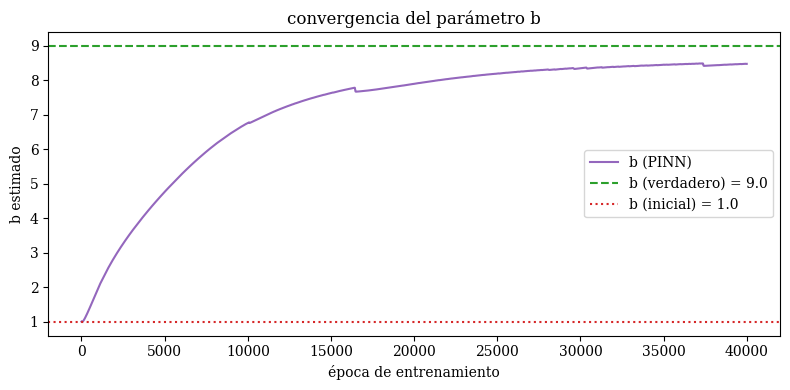


ENTRENANDO PACIENTE 10/50


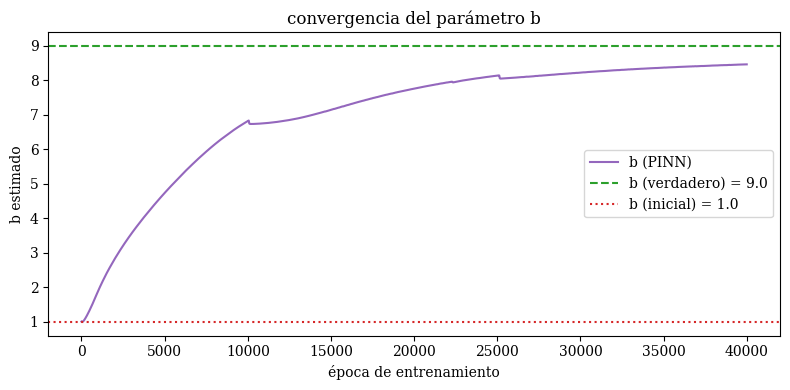


ENTRENANDO PACIENTE 11/50


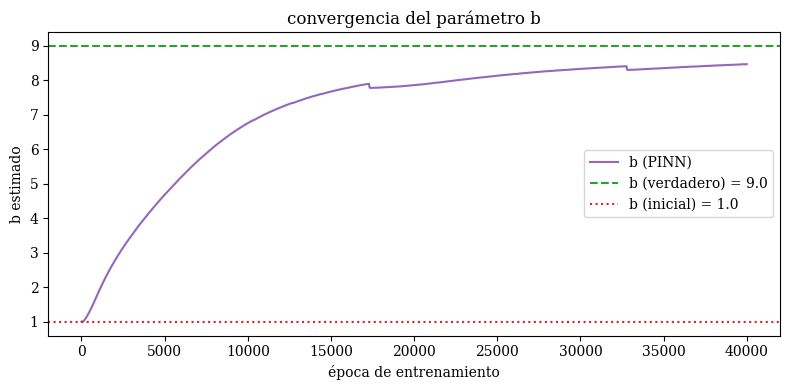


ENTRENANDO PACIENTE 12/50


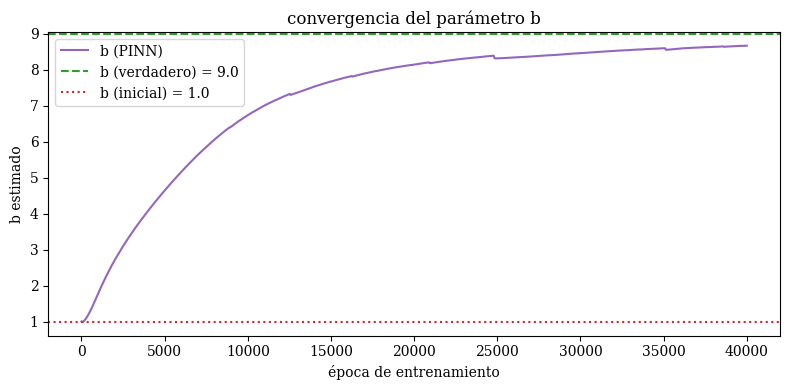


ENTRENANDO PACIENTE 13/50


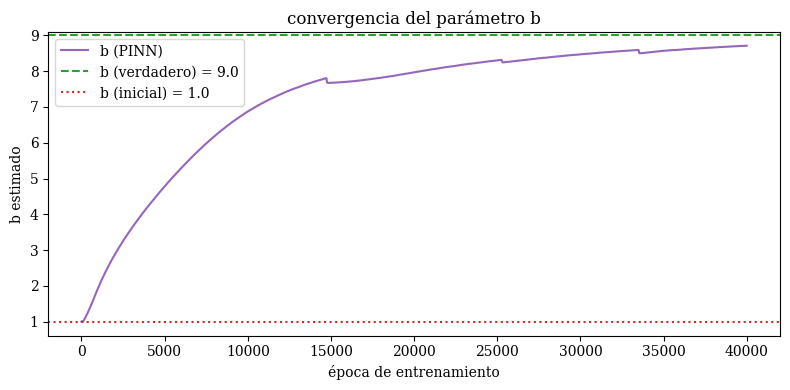


ENTRENANDO PACIENTE 14/50


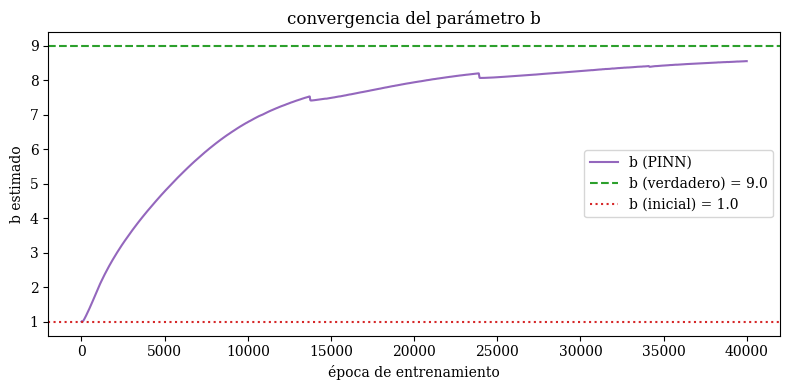


ENTRENANDO PACIENTE 15/50


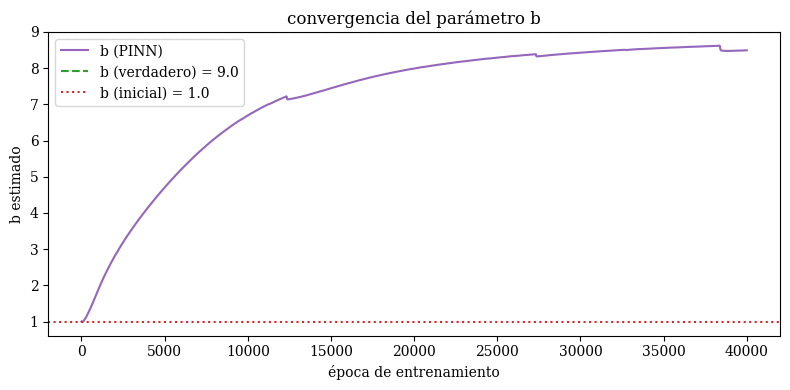


ENTRENANDO PACIENTE 16/50


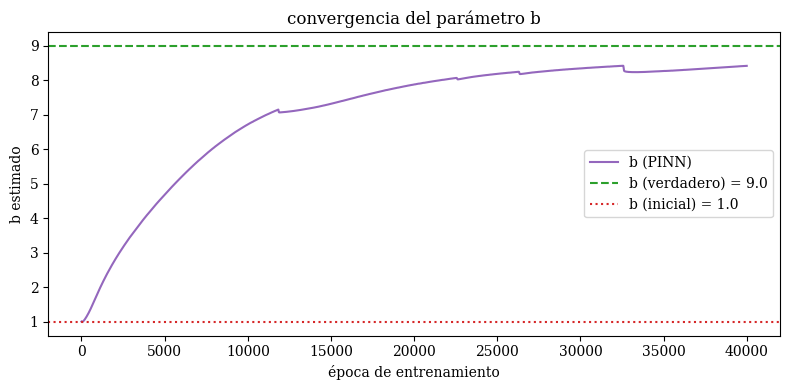


ENTRENANDO PACIENTE 17/50


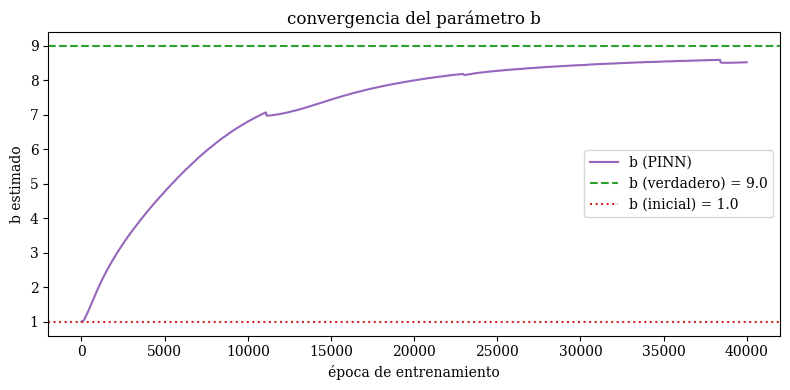


ENTRENANDO PACIENTE 18/50


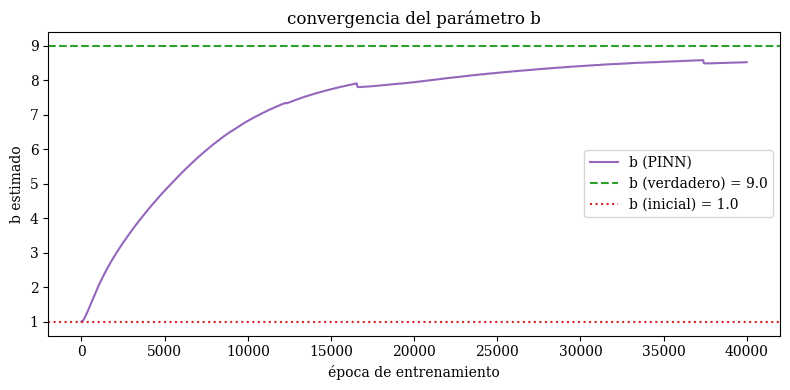


ENTRENANDO PACIENTE 19/50


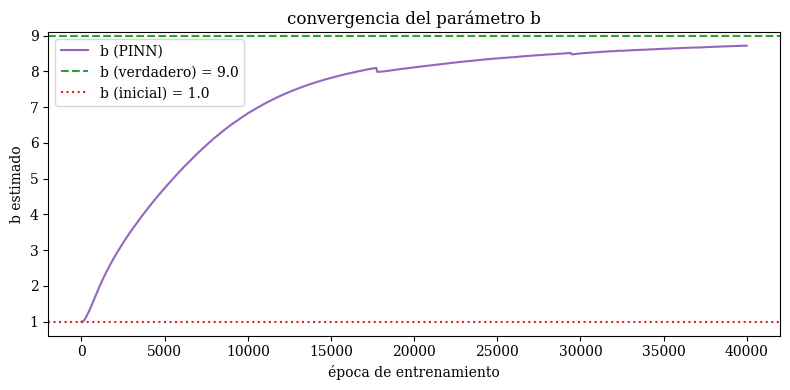


ENTRENANDO PACIENTE 20/50


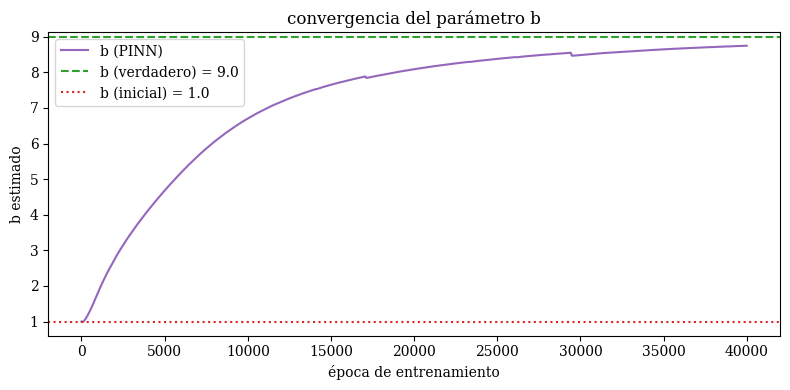


ENTRENANDO PACIENTE 21/50


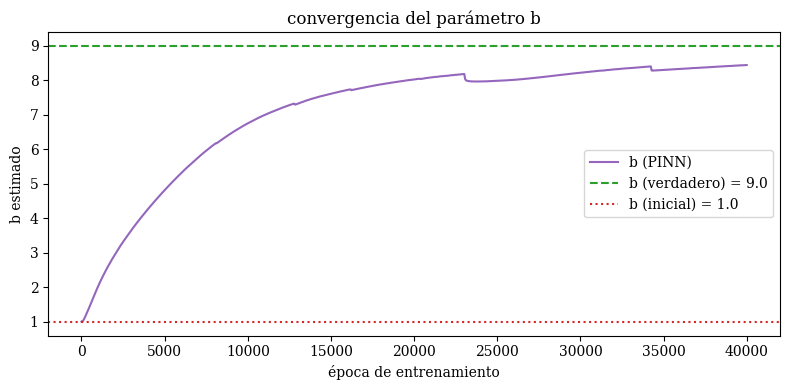


ENTRENANDO PACIENTE 22/50


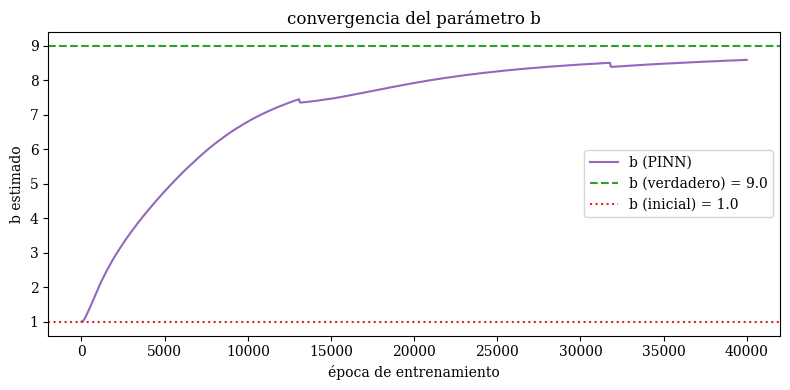


ENTRENANDO PACIENTE 23/50


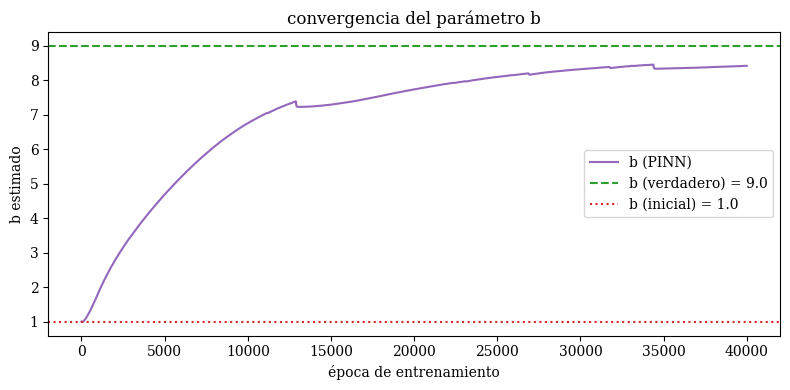


ENTRENANDO PACIENTE 24/50


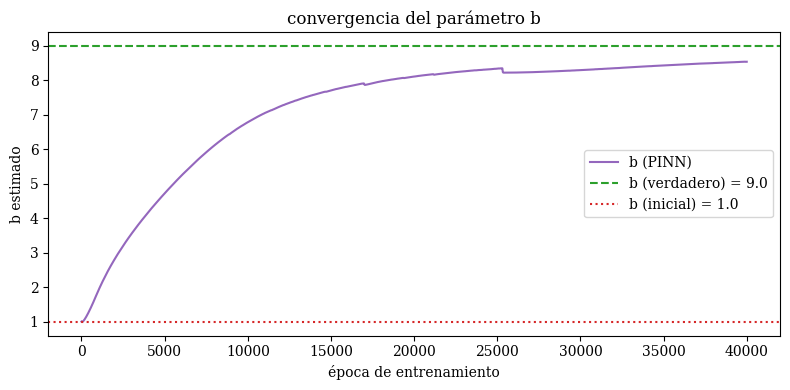


ENTRENANDO PACIENTE 25/50


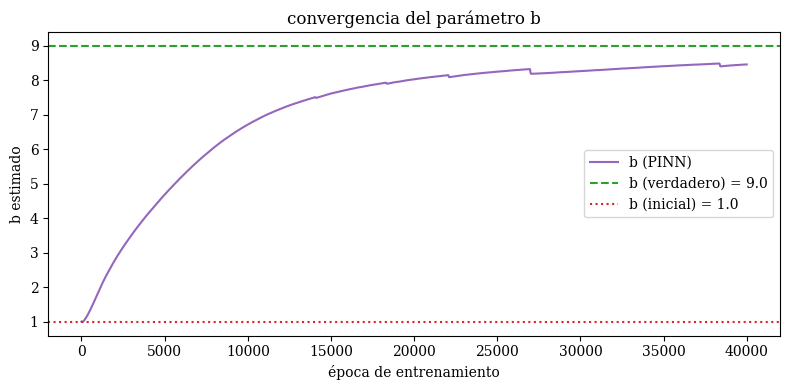


ENTRENANDO PACIENTE 26/50


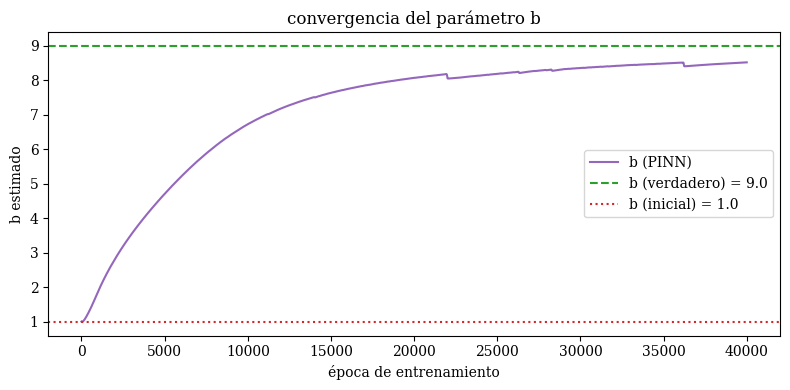


ENTRENANDO PACIENTE 27/50


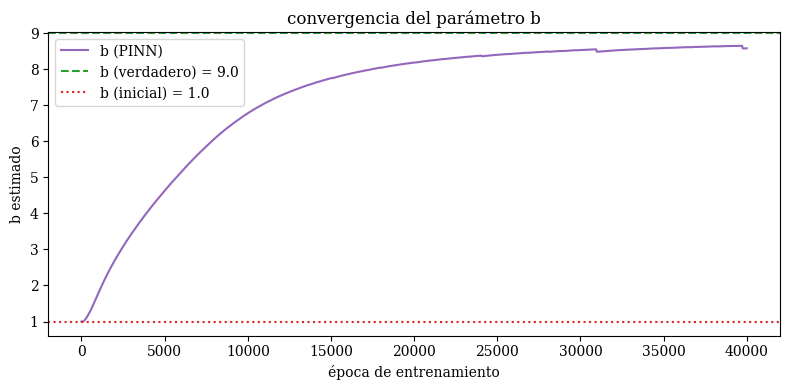


ENTRENANDO PACIENTE 28/50


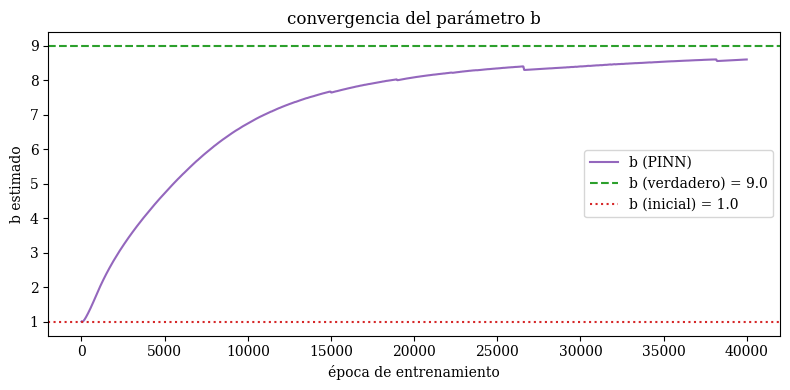


ENTRENANDO PACIENTE 29/50


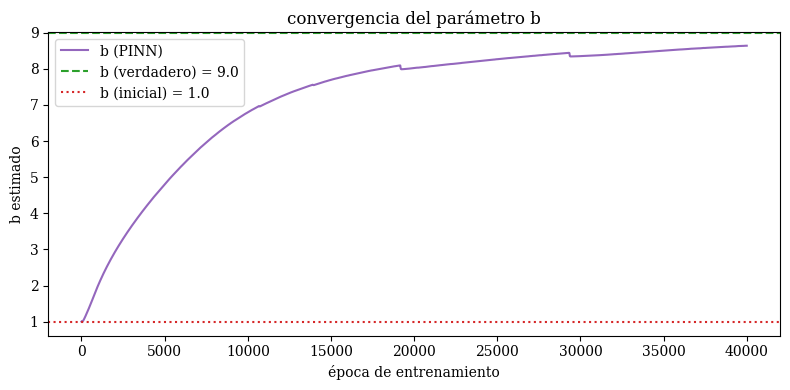


ENTRENANDO PACIENTE 30/50


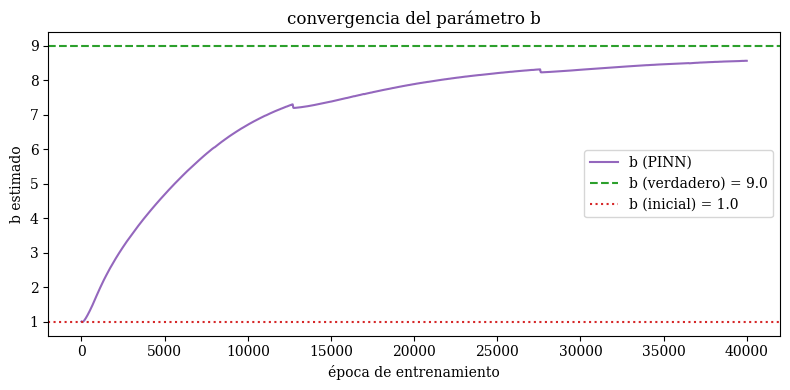


ENTRENANDO PACIENTE 31/50


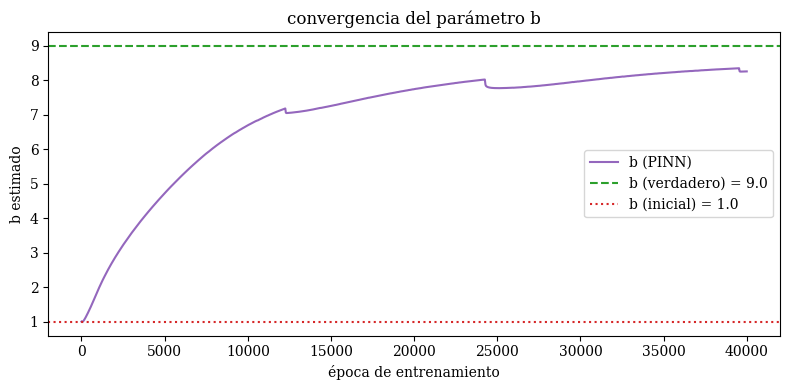


ENTRENANDO PACIENTE 32/50


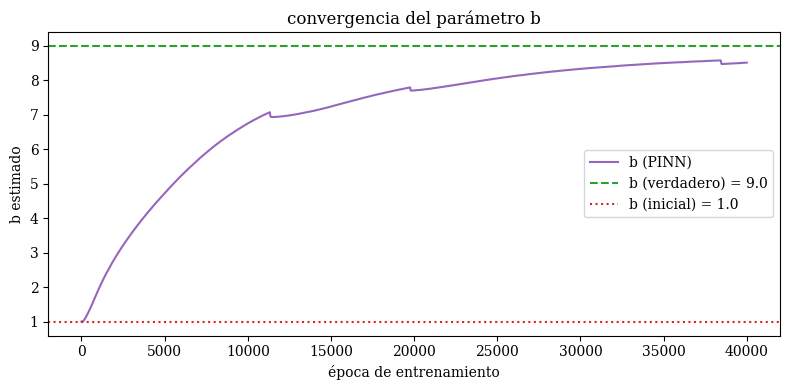


ENTRENANDO PACIENTE 33/50


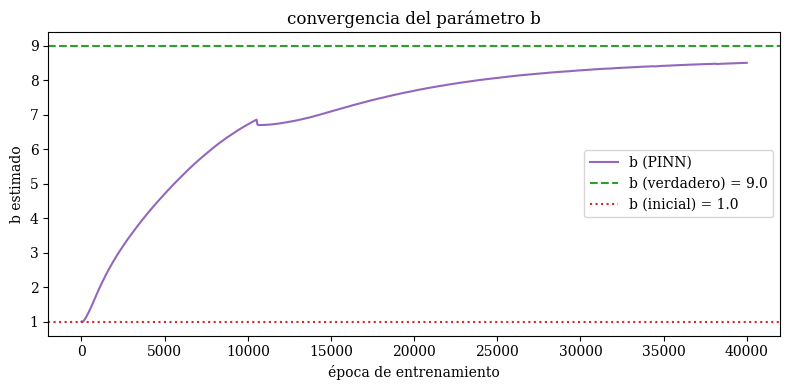


ENTRENANDO PACIENTE 34/50


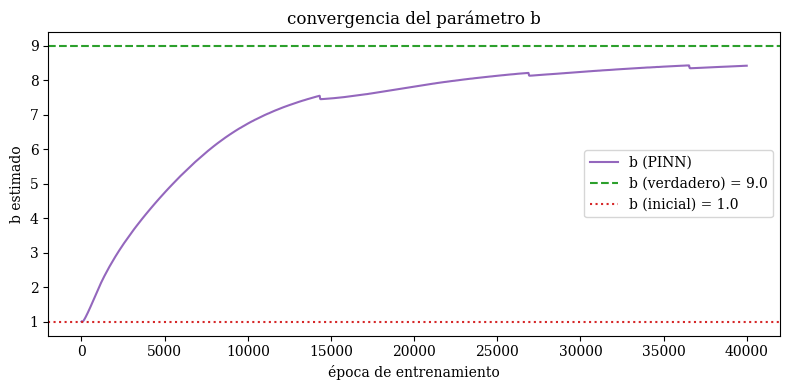


ENTRENANDO PACIENTE 35/50


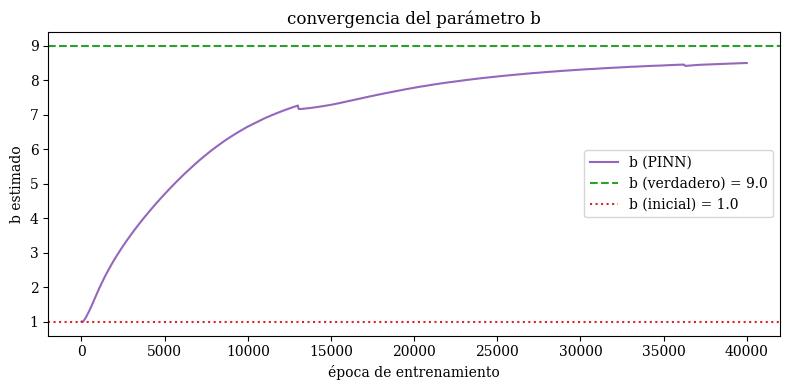


ENTRENANDO PACIENTE 36/50


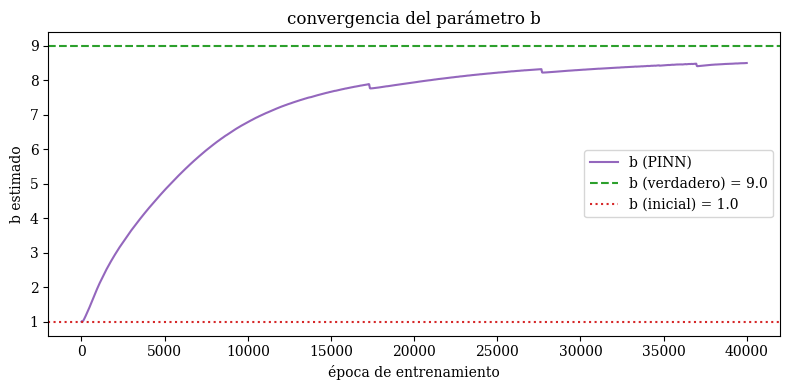


ENTRENANDO PACIENTE 37/50


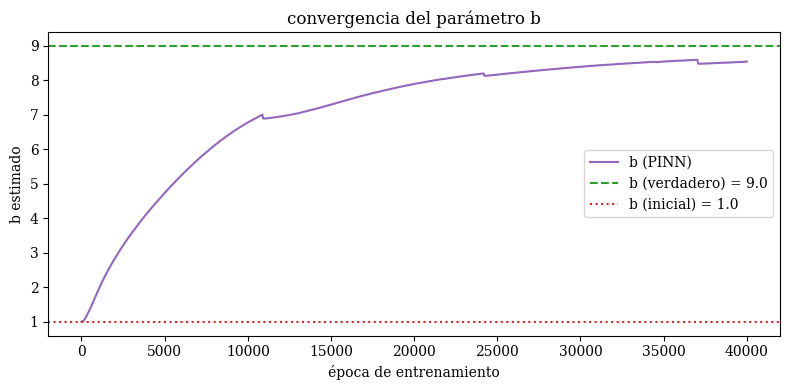


ENTRENANDO PACIENTE 38/50


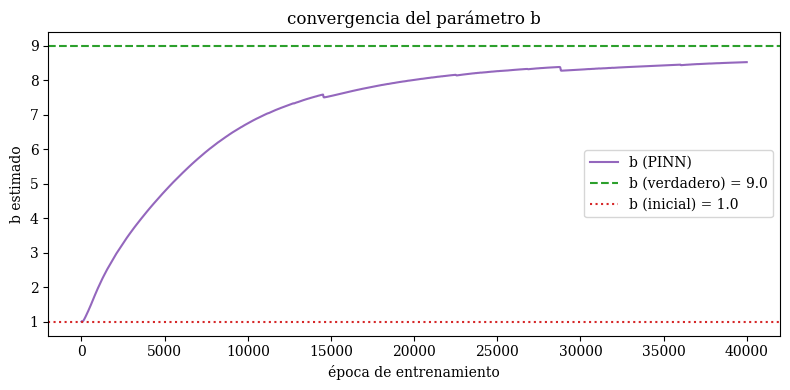


ENTRENANDO PACIENTE 39/50


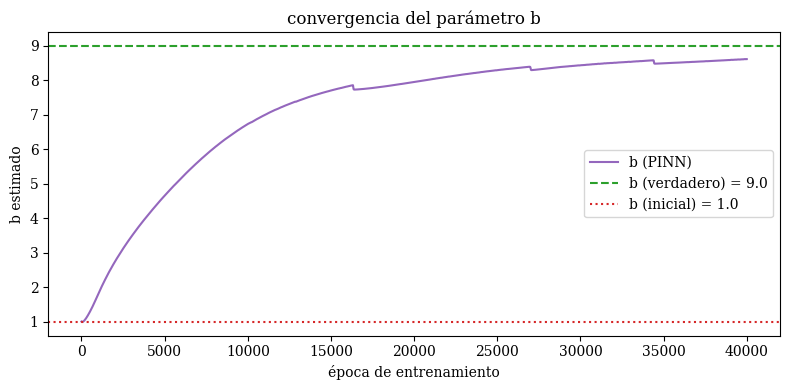


ENTRENANDO PACIENTE 40/50


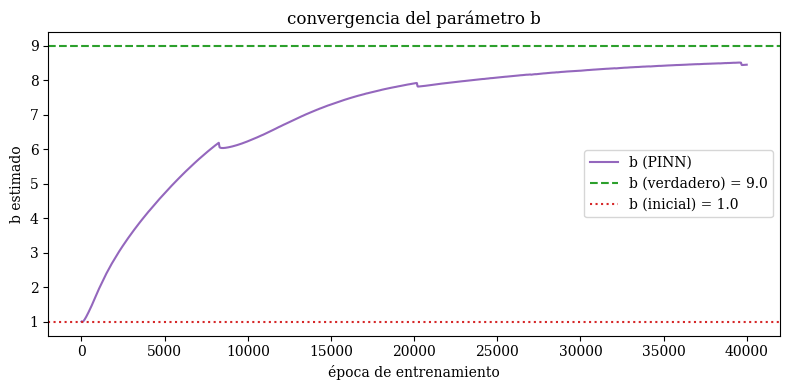


ENTRENANDO PACIENTE 41/50


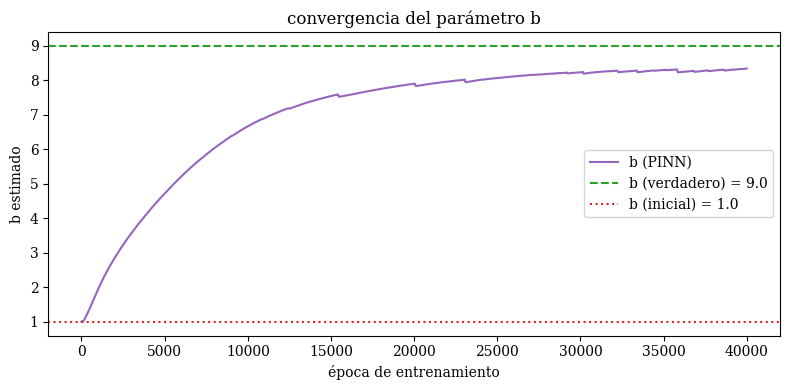


ENTRENANDO PACIENTE 42/50


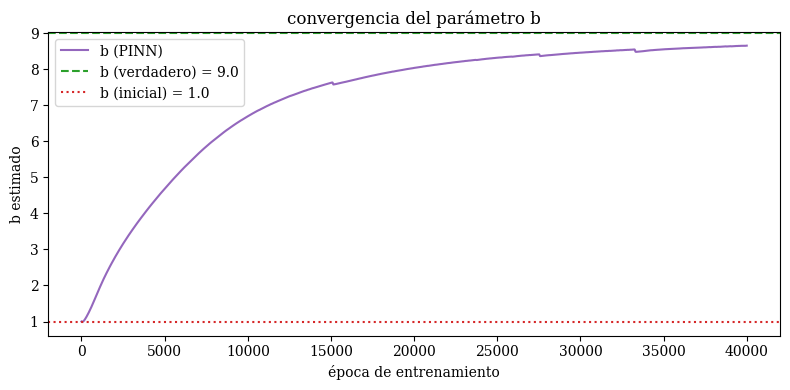


ENTRENANDO PACIENTE 43/50


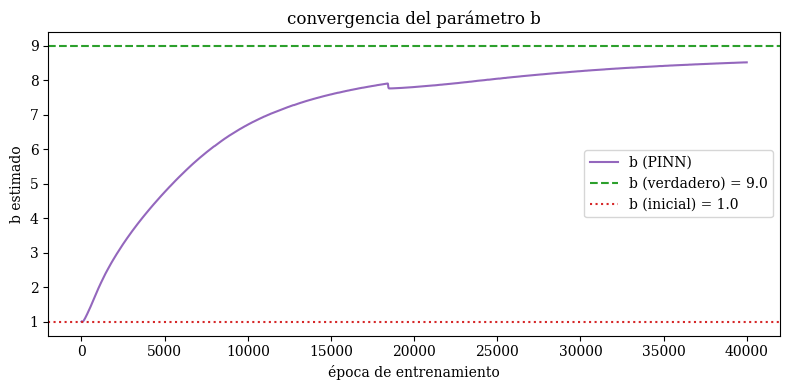


ENTRENANDO PACIENTE 44/50


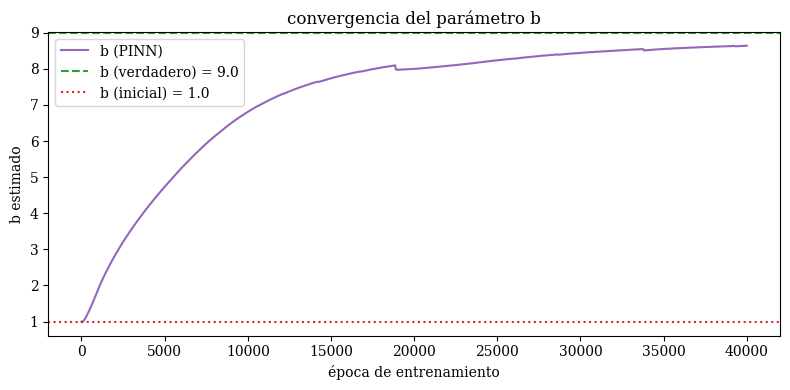


ENTRENANDO PACIENTE 45/50


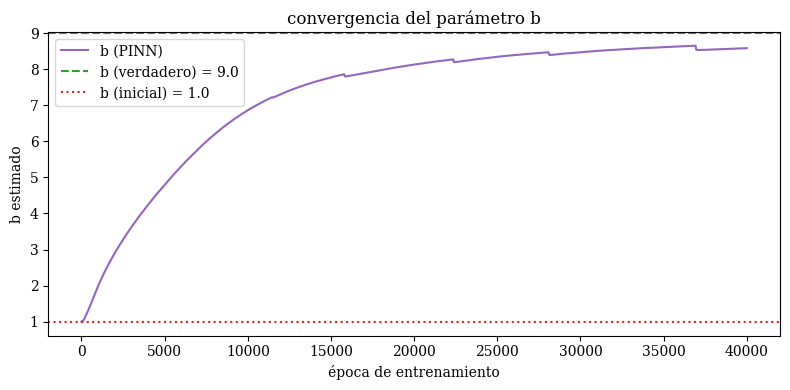


ENTRENANDO PACIENTE 46/50


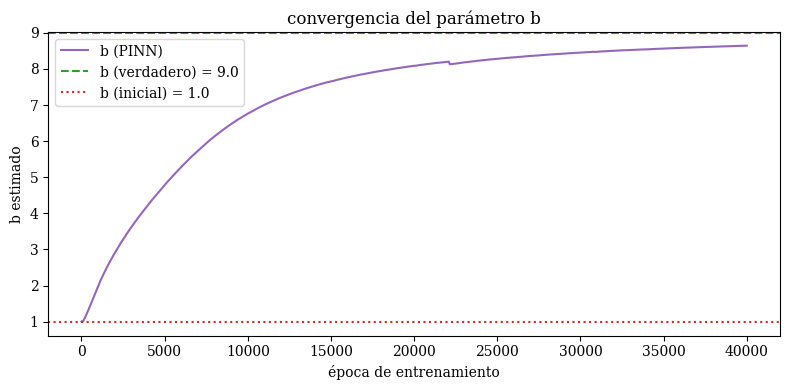


ENTRENANDO PACIENTE 47/50


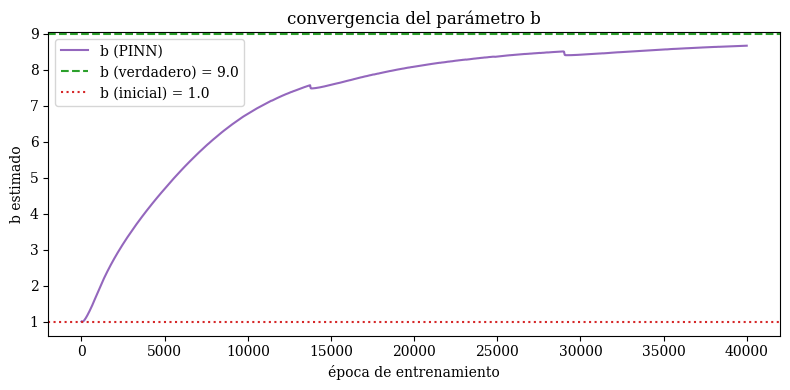


ENTRENANDO PACIENTE 48/50


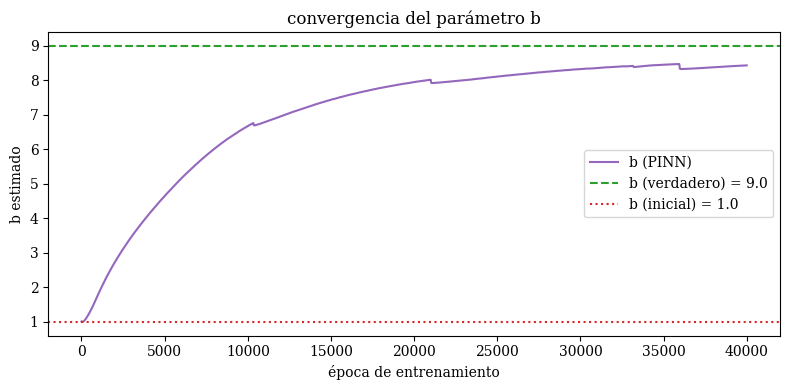


ENTRENANDO PACIENTE 49/50


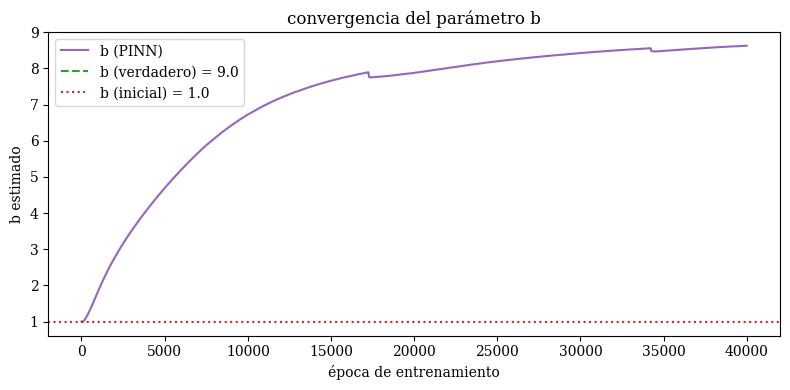


ENTRENANDO PACIENTE 50/50


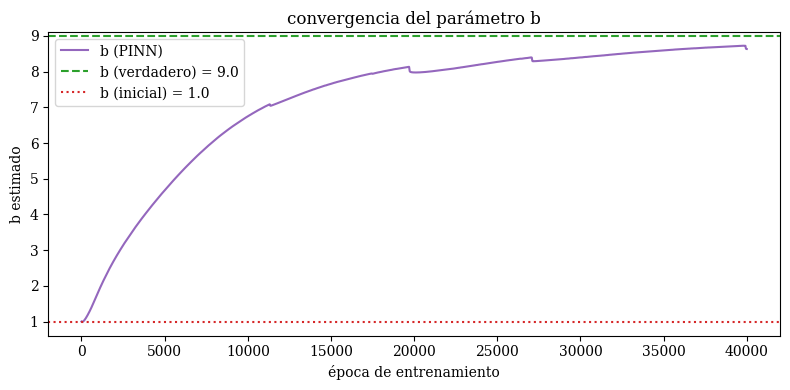


SIMULACIÓN GLOBAL COMPLETADA
Tiempo total de ejecución: 7h 38m 54s


In [ ]:
N_PATIENTS = 50
N_EPOCHS = 40000
N_PHYS = 1000
N_OBS = 50

lambda_data = 1
lambda_phys = 15

# Listas globales para guardar los resultados finales de TODOS los pacientes
final_b_est = []

all_b_vals = []

all_x_preds = []
all_y_preds = []
all_v_preds = []

print(f"INICIANDO SIMULACIÓN PARA {N_PATIENTS} PACIENTES \n")

tiempo_inicio_total = time.time()

for paciente in range(N_PATIENTS):
    print(f"\n" + "="*50)
    print(f"ENTRENANDO PACIENTE {paciente + 1}/{N_PATIENTS}")
    print("="*50)

    # 1. Semilla por paciente
    torch.manual_seed(42 + paciente)
    np.random.seed(42 + paciente)

    # 2. Generación de datos con ruido
    t_data_np = np.linspace(0, TAU_MAX, N_OBS)

    sol_paciente = solve_ivp(
        model_adim, [0, TAU_MAX], [x0, y0, v0],
        args=(r_true, a_true, b_true, c), t_eval=t_data_np, method='LSODA'
    )

    ruido = 0.05
    x_data_np = sol_paciente.y[0] * (1 + ruido * np.random.randn(N_OBS))
    y_data_np = sol_paciente.y[1] * (1 + ruido * np.random.randn(N_OBS))
    v_data_np = sol_paciente.y[2] * (1 + ruido * np.random.randn(N_OBS))

    t_data = torch.tensor(t_data_np, dtype=torch.float32).view(-1, 1)
    x_data = torch.tensor(x_data_np, dtype=torch.float32).view(-1, 1)
    y_data = torch.tensor(y_data_np, dtype=torch.float32).view(-1, 1)
    v_data = torch.tensor(v_data_np, dtype=torch.float32).view(-1, 1)

    # 3. Re-inicializar modelo y parámetros
    pinn = VIRO_NN(N_HIDDEN=164, N_LAYERS=5)
    t_physic = torch.linspace(0, TAU_MAX, N_PHYS).view(-1, 1).requires_grad_(True)
    t_test   = torch.linspace(0, TAU_MAX, 500).view(-1, 1)

    # r y a quedan fijos en su valor verdadero; solo b es entrenable
    r_fixed = r_true
    a_fixed = a_true
    b_param = nn.Parameter(torch.tensor([1.0], requires_grad=True))

    optimiser = torch.optim.Adam(
        list(pinn.parameters()) + [b_param], lr=1e-3
    )

    b_vals, losses = [], []

    # 4. Bucle de entrenamiento
    for epoch in range(N_EPOCHS):
        optimiser.zero_grad()

        pred_phys = pinn(t_physic)
        xp, yp, vp = pred_phys[:, 0:1], pred_phys[:, 1:2], pred_phys[:, 2:3]

        ones = torch.ones_like(xp)
        dxdt = torch.autograd.grad(xp, t_physic, ones, create_graph=True)[0]
        dydt = torch.autograd.grad(yp, t_physic, ones, create_graph=True)[0]
        dvdt = torch.autograd.grad(vp, t_physic, ones, create_graph=True)[0]

        res_x = dxdt - (r_fixed * xp * (1 - xp - yp) - a_fixed * xp * vp)
        res_y = dydt - (a_fixed * xp * vp - yp)
        res_v = dvdt - (b_param * yp - a_fixed * xp * vp - c * vp)

        loss_phys = torch.mean(res_x**2 + res_y**2 + res_v**2)

        pred_data = pinn(t_data)
        loss_data = torch.mean(
            0.5  * (pred_data[:, 0:1] - x_data)**2 +
            15.0 * (pred_data[:, 1:2] - y_data)**2 +
            0.2  * (pred_data[:, 2:3] - v_data)**2
        )

        loss = lambda_phys * loss_phys + lambda_data * loss_data
        loss.backward()
        optimiser.step()

        b_vals.append(b_param.item())
        losses.append(loss.item())

    # 5. Guardar resultados — predicciones en t_test (500 puntos, numpy, sin gradiente)
    final_b_est.append(b_vals[-1])

    all_b_vals.append(b_vals)

    with torch.no_grad():
        u = pinn(t_test)
        x_pred = u[:, 0].numpy()   # shape (500,)
        y_pred = u[:, 1].numpy()
        v_pred = u[:, 2].numpy()

    all_x_preds.append(x_pred)    # ← numpy arrays de t_test, no tensores de t_physic
    all_y_preds.append(y_pred)
    all_v_preds.append(v_pred)

    # 6. Plot per-paciente (convergencia del parámetro b)
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"]  = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
    plt.rcParams["font.size"]   = 10

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(b_vals, color='tab:purple', lw=1.5, label='b (PINN)')
    ax.axhline(b_true,    color='tab:green', ls='--', lw=1.5, label=f'b (verdadero) = {b_true}')
    ax.axhline(b_vals[0], color='tab:red',   ls=':',  lw=1.5, label=f'b (inicial) = {b_vals[0]:.1f}')
    ax.set_title('convergencia del parámetro b')
    ax.set_xlabel('época de entrenamiento')
    ax.set_ylabel('b estimado')
    ax.legend()
    ax.grid(False)

    plt.tight_layout()
    plt.savefig(f'convergencia_paciente_{paciente+1}.pdf', bbox_inches='tight')
    plt.show()

# ── Cronómetro final ──────────────────────────────────────────────────────────
tiempo_fin_total     = time.time()
tiempo_total_segundos = tiempo_fin_total - tiempo_inicio_total

horas   = int(tiempo_total_segundos // 3600)
minutos = int((tiempo_total_segundos % 3600) // 60)
segundos = int(tiempo_total_segundos % 60)

print("\n" + "="*50)
print("SIMULACIÓN GLOBAL COMPLETADA")
print("="*50)
if horas > 0:
    print(f"Tiempo total de ejecución: {horas}h {minutos}m {segundos}s")
elif minutos > 0:
    print(f"Tiempo total de ejecución: {minutos}m {segundos}s")
else:
    print(f"Tiempo total de ejecución: {segundos} segundos")

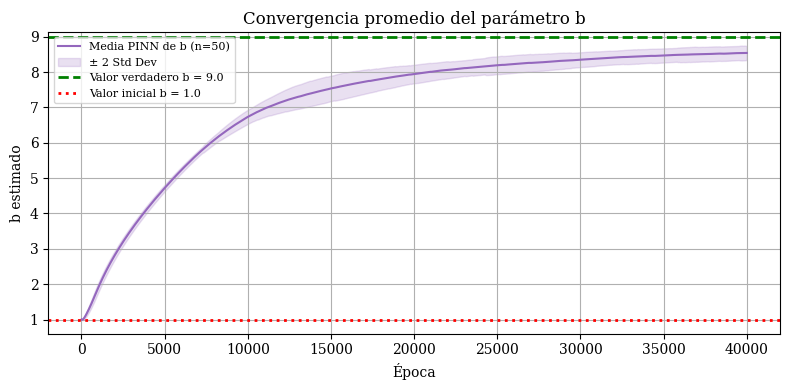

In [ ]:
# --- GRÁFICA DE CONVERGENCIA PROMEDIO ENTRE PACIENTES ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"]   = 10

all_b_vals = np.array(all_b_vals)  # shape: (N_PATIENTS, N_EPOCHS)
b_mean_traj, b_std_traj = all_b_vals.mean(axis=0), all_b_vals.std(axis=0)
epochs = np.arange(N_EPOCHS)

# --- Variable para controlar el multiplicador de la desviación estándar ---
num_std = 2

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epochs, b_mean_traj, color='tab:purple', label=f'Media PINN de b (n={N_PATIENTS})')

ax.fill_between(epochs,
                b_mean_traj - (num_std * b_std_traj),
                b_mean_traj + (num_std * b_std_traj),
                color='tab:purple', alpha=0.2, label=f'± {num_std} Std Dev')

ax.axhline(b_true, color='green', linestyle='--', linewidth=2, label=f'Valor verdadero b = {b_true}')
ax.axhline(1.0, color='red', linestyle=':', linewidth=2, label='Valor inicial b = 1.0')
ax.set_title('Convergencia promedio del parámetro b')
ax.set_xlabel('Época')
ax.set_ylabel('b estimado')
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.savefig('convergencia_promedio_b.pdf', bbox_inches='tight')
plt.show()

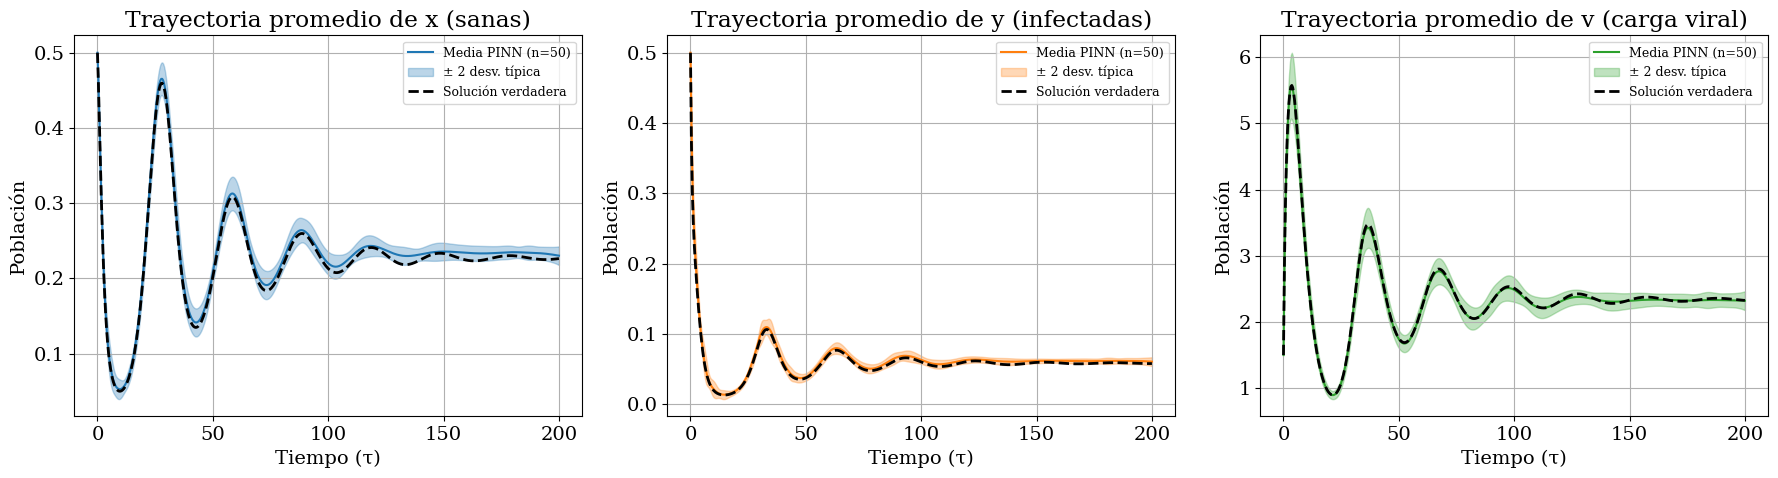

In [ ]:
# ── Gráfica de trayectorias promedio ─────────────────────────────────────────
all_x_preds = np.array(all_x_preds)   # shape (N_PATIENTS, 500)
all_y_preds = np.array(all_y_preds)
all_v_preds = np.array(all_v_preds)

x_mean_traj, x_std_traj = all_x_preds.mean(axis=0), all_x_preds.std(axis=0)
y_mean_traj, y_std_traj = all_y_preds.mean(axis=0), all_y_preds.std(axis=0)
v_mean_traj, v_std_traj = all_v_preds.mean(axis=0), all_v_preds.std(axis=0)

t_test_np = t_test.numpy().flatten()

sol_verdadera = solve_ivp(
    model_adim, [0, TAU_MAX], [x0, y0, v0],
    args=(r_true, a_true, b_true, c), t_eval=t_test_np, method='LSODA'
)
x_true, y_true, v_true = sol_verdadera.y

num_std = 2

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"]   = 14

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

estado_info = [
    (x_mean_traj, x_std_traj, x_true, 'x (sanas)',       'tab:blue',   axes[0]),
    (y_mean_traj, y_std_traj, y_true, 'y (infectadas)',   'tab:orange', axes[1]),
    (v_mean_traj, v_std_traj, v_true, 'v (carga viral)',  'tab:green',  axes[2]),
]

for mean_traj, std_traj, true_traj, name, color, ax in estado_info:
    ax.plot(t_test_np, mean_traj, color=color, lw=1.5,
            label=f'Media PINN (n={N_PATIENTS})')
    ax.fill_between(
        t_test_np,
        mean_traj - num_std * std_traj,
        mean_traj + num_std * std_traj,
        color=color, alpha=0.3, label=f'± {num_std} desv. típica'
    )
    ax.plot(t_test_np, true_traj, color='black', ls='--', lw=2,
            label='Solución verdadera')
    ax.set_title(f'Trayectoria promedio de {name}')
    ax.set_xlabel('Tiempo (τ)')
    ax.set_ylabel('Población')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('trayectorias_promedio.pdf', bbox_inches='tight')
plt.show()


ANÁLISIS ESTADÍSTICO COMPLETO (n=50 pacientes)

Parámetro b (real = 9.0)
  Media ± Std:            8.5403 ± 0.1018  (SEM = 0.0144)
  Sesgo (bias):           -0.4597  |  Error relativo: +5.11%
  RMSE:                   0.4706
  IC 95% (t-Student):     [8.5113, 8.5692]
  IC 95% (bootstrap):     [8.5125, 8.5675]
  Shapiro-Wilk normalidad: p = 0.7207 (consistente con normal)
  t-test vs valor real:    t = -31.918, p = 0.0000 (diferencia significativa)
  Cohen's d (tamaño efecto): -4.514
  Outliers detectados:     1 paciente(s) -> índices [30]


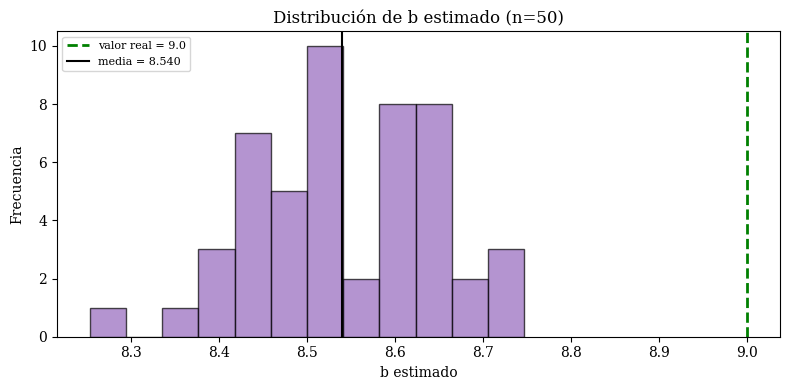

In [ ]:
# --- ANÁLISIS ESTADÍSTICO COMPLETO (n=50) ---
from scipy import stats

final_b_est = np.array(final_b_est)

name = 'b'
est = final_b_est
true_val = b_true
color_bar = 'tab:purple'

print("\n" + "="*60)
print(f"ANÁLISIS ESTADÍSTICO COMPLETO (n={N_PATIENTS} pacientes)")
print("="*60)

n = len(est)
mean_est = np.mean(est)
std_est = np.std(est, ddof=1)
sem = std_est / np.sqrt(n)

bias = mean_est - true_val
rel_error_pct = (bias / true_val) * 100
rmse = np.sqrt(np.mean((est - true_val)**2))

# IC 95% paramétrico (t-Student)
ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean_est, scale=sem)

# IC 95% por bootstrap (respaldo no paramétrico, útil si n grande y/o no hay normalidad)
boot_means = np.array([
    np.mean(np.random.choice(est, size=n, replace=True))
    for _ in range(10000)
])
boot_ci_low, boot_ci_high = np.percentile(boot_means, [2.5, 97.5])

# Test de normalidad (Shapiro-Wilk) -- orientativo, con n=50 ya es razonable aplicarlo
shapiro_stat, shapiro_p = stats.shapiro(est)

# t-test de una muestra + tamaño del efecto (Cohen's d)
t_stat, p_value = stats.ttest_1samp(est, true_val)
cohens_d = bias / std_est

# Detección de outliers (criterio: |z-score| > 2.5)
z_scores = (est - mean_est) / std_est
outliers_idx = np.where(np.abs(z_scores) > 2.5)[0]

resultado = {
    'mean': mean_est, 'std': std_est, 'sem': sem, 'bias': bias,
    'rel_error_pct': rel_error_pct, 'rmse': rmse,
    'ci_low': ci_low, 'ci_high': ci_high,
    'boot_ci_low': boot_ci_low, 'boot_ci_high': boot_ci_high,
    'shapiro_p': shapiro_p, 't_stat': t_stat, 'p_value': p_value,
    'cohens_d': cohens_d, 'outliers_idx': outliers_idx
}

print(f"\nParámetro {name} (real = {true_val})")
print(f"  Media ± Std:            {mean_est:.4f} ± {std_est:.4f}  (SEM = {sem:.4f})")
print(f"  Sesgo (bias):           {bias:+.4f}  |  Error relativo: {abs(rel_error_pct):+.2f}%")
print(f"  RMSE:                   {rmse:.4f}")
print(f"  IC 95% (t-Student):     [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  IC 95% (bootstrap):     [{boot_ci_low:.4f}, {boot_ci_high:.4f}]")
print(f"  Shapiro-Wilk normalidad: p = {shapiro_p:.4f}",
      "(consistente con normal)" if shapiro_p > 0.05 else "(se desvía de normal)")
print(f"  t-test vs valor real:    t = {t_stat:.3f}, p = {p_value:.4f}",
      "(diferencia significativa)" if p_value < 0.05 else "(no significativa)")
print(f"  Cohen's d (tamaño efecto): {cohens_d:.3f}")
print(f"  Outliers detectados:     {len(outliers_idx)} paciente(s) -> índices {outliers_idx.tolist()}")

# --- FIGURA: Histograma de distribución del parámetro b ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"]   = 10

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(est, bins=12, color=color_bar, alpha=0.7, edgecolor='black')
ax.axvline(true_val, color='green', linestyle='--', linewidth=2, label=f'valor real = {true_val}')
ax.axvline(mean_est, color='black', linestyle='-', linewidth=1.5,
           label=f'media = {mean_est:.3f}')
ax.set_title(f'Distribución de {name} estimado (n={N_PATIENTS})')
ax.set_xlabel(f'{name} estimado')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.savefig('distribucion_b.pdf', bbox_inches='tight')
plt.show()